# PHASE 1: PREPARING THE DATASET

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

keys dict_keys(['image', 'label'])
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=72x31 at 0x79027CB761B0>,
 'label': 'Lube'}
keys dict_keys(['image', 'label'])
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=82x31 at 0x79027CB772F0>,
 'label': 'Spencerian'}
keys dict_keys(['image', 'label'])
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=115x31 at 0x79027CB77350>,
 'label': 'accommodatingly'}
successfully saved in subset


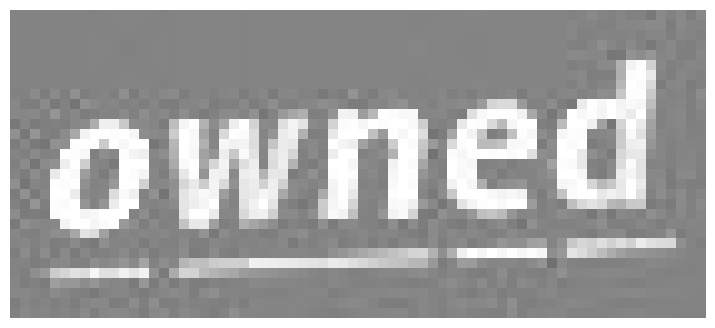

converted successfully


In [1]:
#  Loading and preparing the mjsynth dataset 

from datasets import load_dataset
import pprint
from datasets import Dataset
import matplotlib.pyplot as plt


ds = load_dataset(
    "priyank-m/MJSynth_text_recognition",
     split= "train",
     streaming=True
)

# Inspecting the few samples 
for i, sample in enumerate(ds):
    print("keys", sample.keys())
    pprint.pprint(sample, depth=2)
    if i == 2:
        break

# Storing 1000 dataset in form of hf dataset and converted in python list
ds = ds.take(5000)
subset = list(ds)
print("successfully saved in subset")

# Visualizing one image
sample = subset[230]
image = sample["image"]

# Plot the image in the 10*10 plot
# fig can be used to change the color or save the image 
# ax can be used to make changes in axes
fig, ax = plt.subplots(figsize = (10, 4))
# to plot the image 
ax.imshow(image)
ax.axis('off')
plt.show()

# converting into hf dataset
small_ds2=Dataset.from_list(subset)
print("converted successfully")

In [2]:
# The preprocessing of the mjsynth dataset 
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms.functional as F
import torchvision.transforms as T
from datasets import load_dataset

# Cleaning the dataset
unique_chars = sorted(list(set("".join(small_ds2["label"])))) # Takes whole row of label feature and extracts the unique characters and stores in form of list.
my_dictionary = {char: idx for idx, char in enumerate(unique_chars, start=1)} # Build the dictionary with index 0 reserved for the CTC token.

# Instantiating a transform pipeline
my_transform_pipeline = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((32, 128)), 
    T.ToTensor()
])

# create the custom collection function
class MJSynthDataset(Dataset):
    def __init__(self, small_ds2, char_to_idx_dict, transform=None):
        self.small_ds2 = small_ds2
        self.char_to_idx_dict = char_to_idx_dict
        self.transform = transform

    def __len__(self):
        return len(self.small_ds2)

    def __getitem__(self, index):
        sample = self.small_ds2[index] # Grapping a sample from the dataset
        image = sample["image"]
        label = sample["label"]

        # If transform pipeline is passed as argument then pass the image through the transform pipeline 
        if self.transform is not None:
            image_tensor = self.transform(image)
        else:
            # If no transform pipeline is provided then convert the image into tensor object
            image_tensor = F.to_tensor(image)

        # convert characters into integers_id
        integer_ids = []
        for char in label:
            index = self.char_to_idx_dict.get(char, 0)
            integer_ids.append(index)

        label_tensor = torch.tensor(integer_ids, dtype=torch.int64)

        # Return the processed pieces
        return image_tensor, label_tensor

# create collate fn different label tensors sizes and convert them to the same length
# pytorch will hand the batch automatically whatever the getitem returns
def crnn_collate_fn(batch):
    images = []
    labels = []
    labels_length = []

    # unpack the list of tuples 
    for image_tensor, label_tensor in batch:
        images.append(image_tensor)
        labels.append(label_tensor)
        labels_length.append(len(label_tensor))

    images_tensor = torch.stack(images) # This line simply adds images on top of each  
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=0) # This line adds filler values to the shorter labels so all the labels same values
    labels_lengths_tensor = torch.tensor(labels_length, dtype=torch.int64) # THis line simply converts the length into tensor objects
    return images_tensor, labels_padded, labels_lengths_tensor


# initialize the dataset class 
dataset2 = MJSynthDataset (
    small_ds2=small_ds2,
    char_to_idx_dict=my_dictionary,
    transform=my_transform_pipeline
)


# plug it into the dataLoader
my_dataloader2 = DataLoader(
    dataset=dataset2,
    batch_size=32,
    shuffle=True,
    collate_fn=crnn_collate_fn
)

--- BATCH STRUCTURE ---
Stacked Images Tensor Shape: torch.Size([32, 1, 32, 128])
Padded Labels Tensor Shape: torch.Size([32, 13])
Lengths Tensor Shape: torch.Size([32])

Original sequence length (before padding): 9
Decoded Tensor Output: TRANSFERS[PAD/BLANK][PAD/BLANK][PAD/BLANK][PAD/BLANK]


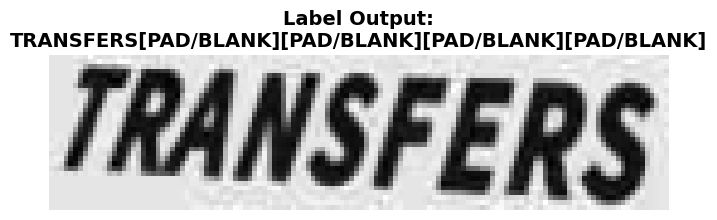

In [3]:
# Testing the preprocessed dataset 

import matplotlib.pyplot as plt
import torch

# 1. Create a reverse dictionary to turn integers back into characters
# We need this to read what the tensor is actually saying
idx_to_char_dict = {idx: char for char, idx in my_dictionary.items()}
# Add a placeholder for 0 so it prints nicely instead of throwing an error
idx_to_char_dict[0] = "[PAD/BLANK]" 

# 2. Grab a single batch of data from your dataloader
# iter() turns the dataloader into an iterator, next() pulls the first batch
images, labels_padded, labels_lengths = next(iter(my_dataloader2))

# 3. Print the architecture of the batch to verify collate_fn worked
print("--- BATCH STRUCTURE ---")
print(f"Stacked Images Tensor Shape: {images.shape}") # Expected: [32, C, 32, 128]
print(f"Padded Labels Tensor Shape: {labels_padded.shape}") # Expected: [32, max_length_in_this_batch]
print(f"Lengths Tensor Shape: {labels_lengths.shape}") # Expected: [32]

# 4. Extract the very first item in the batch
image_0 = images[0]
label_0 = labels_padded[0]
length_0 = labels_lengths[0]

# 5. Decode the padded tensor back into readable text
decoded_text_list = []
for idx in label_0.numpy():
    decoded_text_list.append(idx_to_char_dict[idx])
    
decoded_text = "".join(decoded_text_list)
print(f"\nOriginal sequence length (before padding): {length_0}")
print(f"Decoded Tensor Output: {decoded_text}")

# 6. Set up the matplotlib plot to visually check the image
# PyTorch images are [Channels, Height, Width]. Matplotlib wants [Height, Width, Channels]
image_to_plot = image_0.permute(1, 2, 0).numpy()

plt.figure(figsize=(8, 3))
# If it's a 1-channel grayscale image, squeeze it for matplotlib
if image_to_plot.shape[-1] == 1:
    plt.imshow(image_to_plot.squeeze(), cmap='gray')
else:
    plt.imshow(image_to_plot)

plt.title(f"Label Output:\n{decoded_text}", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

#  Phase 2 BUILDING THE TEXT RECOGNIZER: 

**Overview of this phase**: 
This CNN architecture will take a cropped image of a word and extract its visual features, condensing it into a feature map.
Unlike standard CNNs which compress both height and width equally, OCR CNN compress height but preserve the width as much as possible.

WHY?
BECAUSE: this ensures the resulting feature map is a wide sequence allowing the other layers can read the word from left to right 

Work in the OCR feature extractor class 
1. added convolution layer( more info are in the group mit paper and medium article) 
2. added batch normalization
3. added rectified linear activation
3. added a pooling layer: In this layer the kernal moves scans 2 rows and and 2 columns outputs the maximum value goes to the next 2x2 part of the matrix does this to entire input.
4. added 4 residual block with pooling layer with each block


This are just bunch of layer being added through which the input image will be passed.

In [4]:
# Building the CNN feature extractor 

import torch
import torch.nn as nn

class ResidualBlock(nn.Module): # this class has inherited the class module in file nn
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__() # This line passes my class and the objects to the parent class constructor 

        # First convolution layer
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)

        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # Second convolution layer
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # shortcut connection
        self.downsample = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Add the skip connection before the final activation
        out += identity
        out = self.relu(out)

        return out


class OCRFeatureExtractor(nn.Module):
    
    def __init__(self, input_channels=1):
        # Set input_channels=1 for Grayscale, 3 for RGB
        super(OCRFeatureExtractor, self).__init__()
        
        # Block 0: Initial Convolution
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) 

        # Block 1: 64 -> 128 Channels
        self.layer1 = ResidualBlock(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) 

        # Block 2: 128 -> 256 Channels (Rectangular Pooling begins here)
        self.layer2 = ResidualBlock(128, 256)
        # kernel_size=(2, 1) halves the height, but keeps width exactly the same
        self.pool3 = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)) 

        # Block 3: 256 -> 512 Channels
        self.layer3 = ResidualBlock(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))

    def forward(self, x):
        # Pass through initial layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool1(x)

        # Pass through residual blocks and pooling
        x = self.layer1(x)
        x = self.pool2(x)

        x = self.layer2(x)
        x = self.pool3(x)

        x = self.layer3(x)
        x = self.pool4(x)
        
        return x

# --- Testing the network architecture ---
if __name__ == "__main__":   #__name__ is a special variable that takes of name of the file if its imported if not then it remains __main__.
    # Example: Batch of 4 grayscale images, height 32, width 128
    dummy_input = torch.randn(4, 1, 32, 128) 
    
    model = OCRFeatureExtractor(input_channels=1)
    feature_map = model(dummy_input)
    
    print(f"Input shape:  {dummy_input.shape}")
    print(f"Output shape: {feature_map.shape}")

Input shape:  torch.Size([4, 1, 32, 128])
Output shape: torch.Size([4, 512, 2, 32])


In [5]:
# Integrating a Sequence model and Building the whole CRNN model

"""input_channels defines channel of the input data.
   Hidden_size refers number of neurons/nodes inside hidden layer so it can learn 256 distinct features. 
   num_layers refers to the number of hidden layers stacked on top of each other.
   num_classes is the number of categories the outputs layer can predict  
"""



class CRNN(nn.Module):
    def __init__(self, input_channels=1, hidden_size=256, num_layers=2, num_classes=37):
        super(CRNN, self).__init__()

        # --- CNN Stage ---
        self.cnn = OCRFeatureExtractor(input_channels)

        # --- Bridge: collapse height dimension ---
        # CNN output: (batch, 512, 2, 64) (batch, number of channel, height, width)
        # After collapsing height: (batch, 64, 1024)  ← 512*2 = 1024 features per time step
        self.lstm_input_size = 512 * 2  # channels × height

        # --- LSTM Stage ---
        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,  # features per time step = one timestep should see 1024 number of patterns 
            hidden_size=hidden_size,          # 256
            num_layers=num_layers,            # stacked LSTMs
            batch_first=True,                 # (batch, timesteps, features)
            bidirectional=True,               # reads text left→right AND right→left
            dropout=0.2                       # dropout between LSTM layers
        )

        # --- Output: map LSTM output to character classes ---
        # bidirectional → hidden_size * 2
        """It will convert the 256*2=512 numbers in the vector into 36 numbers in the vector mapping the num_clases
            that is the outputs where each number represent the character prediction by the model.
        """
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # Step 1: CNN feature extraction
        x = self.cnn(x)
        # x shape: (batch, 512, 2, 64) (batch, channel, height, width)

        # Step 2: Reshape for LSTM
        batch, channels, height, width = x.size()
        x = x.permute(0, 3, 1, 2) # →(batch, width, channels, height) change position here
        x = x.reshape(batch, width, channels * height) # can do operations here between 
        # x shape: (batch, 64, 1024)  ← 64 time steps, 1024 features each

        # Step 3: LSTM sequence modeling (sequence, timesteps, features)
        x, _ = self.lstm(x) 
        # x shape: (batch, 64, 512)  ← 512 = 256 * 2 (bidirectional)

        # Step 4: Project to character classes at each time step
        x = self.fc(x)
        # x shape: (batch, 64, num_classes)

        return x


# --- Test ---
if __name__ == "__main__":
    dummy_input = torch.randn(4, 1, 32, 128)

    model = CRNN(input_channels=1, hidden_size=256, num_layers=2, num_classes=37)
    output = model(dummy_input)

    print(f"Input shape: {dummy_input.shape}")   # (4, 1, 32, 128)
    print(f"Output shape: {output.shape}")        # (4, 64, 37)
    print(f"→ 64 time steps, 37 class scores per step")

Input shape: torch.Size([4, 1, 32, 128])
Output shape: torch.Size([4, 32, 37])
→ 64 time steps, 37 class scores per step


In [6]:
# Training Loop for the text recognizer Implementing the ctc loss and Training loop

import torch
import torch.nn as nn
import torch.nn.functional as F
import time

# 1. Device Configuration (Leverage GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training pipeline running on device: {device}")

# Move your instantiated model to the selected device
model = CRNN(input_channels=1, hidden_size=256, num_layers=2, num_classes=37)
model = model.to(device)

# 2. Define Hyperparameters
NUM_EPOCHS = 10
BEST_LOSS = float('inf')

# Define your CTC loss and Optimizer
# Note: Ensure num_classes in your model includes +1 for the CTC blank token
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("\n--- Starting Training Loop Pipeline ---")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    model.train() # Set network to training mode (activates Dropout / BatchNorm)
    
    running_loss = 0.0
    batch_count = 0
    
    # Iterate through your prepared PyTorch DataLoader
    for batch_idx, (images, labels, labels_length) in enumerate(my_dataloader2):
        # Move inputs and labels to GPU / CPU device
        images = images.to(device)
        labels = labels.to(device)
        
        # Clear out historical gradients
        optimizer.zero_grad()
        
        # 3. Forward Pass
        outputs = model(images)

        # output is permuted
        outputs = outputs.permute(1, 0, 2)
        
        # 4. Format for CTC Loss Calculation
        log_probs = F.log_softmax(outputs, dim=2)
        
        # Define dimension variables dynamically based on batch
        curr_batch_size = images.size(0)
        time_steps = outputs.size(0) 
        
        # Create lengths tensors needed by nn.CTCLoss (Kept on CPU for stability)
        input_lengths = torch.full(size=(curr_batch_size,), fill_value=time_steps, dtype=torch.long, device='cpu')
        target_lengths = labels_length.to(device='cpu', dtype=torch.long)
        
        # 5. Compute Loss & Backpropagate
        loss = criterion(log_probs, labels, input_lengths, target_lengths)
        
        # Guard against gradient explosions (infinite values)
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"Warning: Met NaN/Inf loss at Epoch {epoch+1}, Batch {batch_idx}. Skipping step.")
            continue
            
        loss.backward()
        
        # Gradient Clipping to keep LSTM stable
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()
        
        # Track statistics
        running_loss += loss.item()
        batch_count += 1
        
        # Print update every 10 batches
        if batch_idx % 10 == 0 and batch_idx > 0:
            current_avg = running_loss / batch_count
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Batch [{batch_idx}/{len(my_dataloader2)}] | Live CTC Loss: {current_avg:.5f}")

    
    # 6. Epoch Summary and Monitoring Metrics
    epoch_duration = time.time() - start_time
    epoch_loss = running_loss / max(1, batch_count)
    
    print(f"\n>> Epoch {epoch+1} Complete | Avg Epoch Loss: {epoch_loss:.5f} | Time Taken: {epoch_duration:.2f}s")
    print("-" * 60)
    
    # 7. Checkpointing: Save the best model weights dynamically
    if epoch_loss < BEST_LOSS:
        BEST_LOSS = epoch_loss
        torch.save(model.state_dict(), "best_crnn_ocr_model.pth")
        print(f"Checkpoint saved! New lowest loss achieved: {BEST_LOSS:.5f}\n")

print("\nPipeline Complete! Optimal training model weights exported to 'best_crnn_ocr_model.pth'")

torch.save(model.state_dict(), "/kaggle/working/CRNN_text_weight.pth")
print("saved the model")

Training pipeline running on device: cuda

--- Starting Training Loop Pipeline ---

>> Epoch 1 Complete | Avg Epoch Loss: 12.08139 | Time Taken: 5.97s
------------------------------------------------------------
Checkpoint saved! New lowest loss achieved: 12.08139


>> Epoch 2 Complete | Avg Epoch Loss: 0.00000 | Time Taken: 4.30s
------------------------------------------------------------
Checkpoint saved! New lowest loss achieved: 0.00000


>> Epoch 3 Complete | Avg Epoch Loss: 0.00000 | Time Taken: 4.29s
------------------------------------------------------------

>> Epoch 4 Complete | Avg Epoch Loss: 0.00000 | Time Taken: 4.29s
------------------------------------------------------------

>> Epoch 5 Complete | Avg Epoch Loss: 0.00000 | Time Taken: 4.34s
------------------------------------------------------------

>> Epoch 6 Complete | Avg Epoch Loss: 0.00000 | Time Taken: 4.30s
------------------------------------------------------------

>> Epoch 7 Complete | Avg Epoch Loss: 0.